# Tech Challenge – Pós IA para DEVs (FIAP) - Fase 2
Projeto 1: Otimização de Modelos de Diagnóstico para Saúde da Mulher

# Sumário

1 - Contexto  
2 - Configuração do Ambiente e Carga de Dados (Google Colab)  
3 - Pré-processamento  
4 - Modelo de Baseline / Modelo da Fase 1  
5 - Equidade entre grupos demográficos: definição prática e limitações do dataset  
7 - Função Fitness do Algoritmo Genético  
8 - Algoritmo Genético  
10 - Experimentos  
11 - Comparação: Modelo da Fase 1 vs Algoritmo Genético  
12 - Avaliação detalhada do melhor modelo obtido pelo Algoritmo Genético  
13 - Integração com LLM  
14 - Avaliação qualitativa das respostas da LLM

# 1 - Contexto

A **Fase 1** construiu um pipeline completo de diagnóstico de câncer de mama, com:
- EDA, pré-processamento e vários modelos;
- Comparação entre algoritmos;
- Escolha de um modelo final e **otimização via GridSearchCV**;
- O modelo final escolhido foi uma Regressão Logística com padronização dos dados via StandardScaler, redução de dimensionalidade com PCA (95%), hiperparâmetro C = 0,23 e Class_weight = "balanced".

**O que foi mantido da Fase 1 (baseline)**:
- Mesmo dataset e mesma tarefa (classificação binária: maligno vs benigno);
- Mesmo estilo de pipeline (Scaler + PCA + Classificador).

**O que foi feito na Fase 2**
- **Algoritmo Genético** para otimização de hiperparâmetros C e Class_weight e para o percentual da variação do PCA.
- Função fitness alinhada à saúde da mulher:
  - **Recall (sensibilidade)** como prioridade (reduzir falsos negativos);
  - **Especificidade** para evitar muitos alarmes falsos em triagem;
  - **F1-score** para equilíbrio;
  - **Equidade** entre subgrupos demográficos, para reduzir discrepâncias de performance entre subgrupos demográficos.
    - Como o dataset não tem dados demográficos, foi criado um conjunto de dados de idade e etnia para simular dados demográficos (dados_demograficos_aleatorios_idade_etnia.csv)
- Realizado **3 experimentos** ()
- Comparação com o modelo da fase 1 (baseline)
- **LLM** para interpretabilidade e comunicação do resultado.
  - Salvar respostas para dataset da Fase 3
  - Análise das respostas do LLM

# 2 - Configuração do Ambiente e Carga de Dados (Google Colab)

O dataset é consumido diretamente de um repositório remoto (GitHub) através de um link de download direto estruturado.

In [ ]:
import numpy as np
import random
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
import re
from openai import OpenAI

from google.colab import userdata

userdata.get('OPENAI_API_KEY')

import os
import json # Added as `json.dumps` is used below

# Define uma semente fixa para garantir reprodutibilidade dos resultados.
RANDOM_STATE = 42

# Configura a semente do NumPy para controlar a aleatoriedade.
np.random.seed(RANDOM_STATE)

# Define o estilo padrão dos gráficos do Seaborn.
sns.set_style("whitegrid")

# Busca a chave no Colab
try:
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
except:
    # Caso você mude para outro ambiente no futuro, ele tenta buscar no sistema
    OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")


if not OPENAI_API_KEY:
    raise ValueError("A chave OPENAI_API_KEY não foi encontrada. Verifique se o 'Notebook access' está ativo no menu Secrets (ícone de chave).")


In [ ]:
# Carregamento dos dados
download_url = "https://raw.githubusercontent.com/marceloklotz/breast-cancer-fiap-segunda-fase/refs/heads/main/breast-cancer.csv"

# Lê o arquivo CSV diretamente da URL e carrega os dados em um DataFrame do Pandas.
df = pd.read_csv(download_url)

# Exibe o formato do dataset (número de linhas e colunas).
print("Formato do dataset:", df.shape)

# Mostra as cinco primeiras linhas para visualizar estrutura e conteúdo inicial.
display(df.head())

# Exibe informações detalhadas sobre o dataset (tipos de dados, valores não nulos, etc.).
df.info()

Formato do dataset: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## 2.1 - Adiciona dados demográficos criados (idade e etnia) para efeitos didáticos.

In [ ]:
demographic_df = pd.read_csv('https://raw.githubusercontent.com/marceloklotz/breast-cancer-fiap-segunda-fase/refs/heads/main/dados_demograficos_aleatorios_idade_etnia.csv')
print("Demographic df loaded.")
display(demographic_df.head())

# Assumindo que demographic_df está implicitamente ordenado da mesma forma que df, adiciona a coluna  'id' para merge
demographic_df['id'] = df['id']

df = pd.merge(df, demographic_df, on='id', how='left')

# Criação de grupos demográficos.
# Serão criados grupos por idade: <30, 30 <= idade < 50 e >= 50 apenas para exemplificar a metodologia. Os grupos foram escolhidos de maneira arbitrária.

def faixa_idade(idade):
    if idade < 30:
        return "Menor que 30 anos"
    elif idade < 50:
        return "Entre 30 e 50 anos"
    else:
        return "Maior de 50 anos"

df["grupo_idade"] = df["idade"].apply(faixa_idade)

display(df.head())

Demographic df loaded.


,idade,etnia
0,35,Preta
1,21,Indígena
2,23,Preta
3,87,Preta
4,66,Branca


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,idade,etnia,grupo_idade
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,35,Preta,Entre 30 e 50 anos
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,21,Indígena,Menor que 30 anos
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,23,Preta,Menor que 30 anos
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,87,Preta,Maior de 50 anos
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,66,Branca,Maior de 50 anos


# 3 - Pré-processamento

Nesta etapa são realizadas as seguintes ações:
- Remoção da coluna `id`, por ser apenas um identificador.
- Mapeamento do `diagnosis` da seguinte forma:
  - **M** = Maligno (classe positiva clínica) -> 1
  - **B** = Benigno -> 0
-  Alteração da coluna `diagnosis` para `target` para seguir uma uniformização de nomenclatura típica de ciência de dados


Para saúde, faz sentido tratar **Maligno como "positivo" (1)**, porque:
- Recall mede quantos casos realmente malignos o modelo detecta;
- Falso negativo (maligno previsto como benigno) é o erro mais perigoso.

In [ ]:
# Remove 'id' (identificador não traz sinal clínico e pode induzir leakage)
# Verifica se a coluna "id" existe no DataFrame.
if "id" in df.columns:
    # Remove a coluna "id", pois é apenas um identificador e não contribui para o modelo.
    df.drop(columns=["id"], inplace=True)

# Mapeamento da variável alvo
# Cria uma nova coluna chamada "target", convertendo valores categóricos em numéricos.
df["target"] = df["diagnosis"].map({"B": 0, "M": 1})

# Remove a coluna original "diagnosis" após a conversão para formato numérico.
df.drop(columns=["diagnosis"], inplace=True)

# Exibe a contagem de cada classe na variável alvo para verificar distribuição.
display(df[["target"]].value_counts())

,count
target,
0,357
1,212


# 4 - Modelo de Baseline / Modelo da Fase 1

Para comparar corretamente, precisamos de um **baseline**:
- mesmo tipo de pipeline,
- mesmos dados,
- sem Algoritmo Genético.

**Escolha do baseline:**  
Vamos usar um pipeline simples e reproduzível definido na Fase 1:
1. `StandardScaler` (padroniza features em mesma escala)
2. `PCA` (reter 95% da variância, como prática comum e similar à Fase 1)
3. `LogisticRegression` (modelo interpretável e forte baseline em tabular)


In [ ]:
# Define as colunas que não devem ser incluídas no conjunto de dados de treino (conjunto X)
cols_to_exclude_from_training = ['target', 'idade', 'grupo_idade', 'etnia']

# Separação treino/teste (hold-out)
# Cria a matriz de variáveis independentes removendo as colunas alvo e que dizem respeito aos dados demográficos (se asusmiu que os dados demográficos não tem relação com o diagnóstico).
X = df.drop(columns=cols_to_exclude_from_training)

# Define a variável alvo que o modelo deverá prever.
y = df["target"]

# Define as variáveis de grupos demográficos
grupo_idade = df["grupo_idade"]
etnia = df["etnia"]

# Divide os dados em conjunto de treino (80%) e teste (20%), mantendo a proporção das classes.
X_train, X_test, y_train, y_test, grupo_idade_train, grupo_idade_test, etnia_train, etnia_test = train_test_split(
    X, y, grupo_idade, etnia,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Pipeline baseline contendo as etapas de pré-processamento e o modelo final.
baseline_pipe = Pipeline([

    # Padroniza as variáveis para média 0 e desvio padrão 1.
    ("scaler", StandardScaler()),

    # Aplica PCA mantendo 95% da variância explicada.
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),

    # Define o modelo de regressão logística.
    ("clf", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        solver="lbfgs",
        penalty="l2",
        C=0.23,                     # Valor de hiperparâmetro otimizado encontrado na fase 1 por meio de GridSearchCV
        class_weight='balanced'     # Valor de hiperparâmetro otimizado encontrado na fase 1 por meio de GridSearchCV
    ))
])

# Treina o pipeline usando os dados de treino.
baseline_pipe.fit(X_train, y_train)

# Gera previsões das classes no conjunto de teste.
y_pred_base = baseline_pipe.predict(X_test)

# Calcula as probabilidades da classe positiva (Maligno).
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]

# Métricas baseline
# Gera a matriz de confusão.
cm_b = confusion_matrix(y_test, y_pred_base)

# Calcula a taxa geral de acertos, precisão, recall (sensibilidade), F1-score.
acc_b = accuracy_score(y_test, y_pred_base)
prec_b = precision_score(y_test, y_pred_base)
rec_b = recall_score(y_test, y_pred_base)
f1_b = f1_score(y_test, y_pred_base)

# Exibe os resultados.
print("=== BASELINE (sem GA) ===")
print(f"Accuracy : {acc_b:.4f}")
print(f"Precision: {prec_b:.4f}")
print(f"Recall   : {rec_b:.4f}  <-- prioridade clínica")
print(f"F1-score : {f1_b:.4f}")
print(f"Matriz de confusão:\n{cm_b}")

=== BASELINE (sem GA) ===
Accuracy : 0.9825
Precision: 1.0000
Recall   : 0.9524  <-- prioridade clínica
F1-score : 0.9756
Matriz de confusão:
[[72  0]
 [ 2 40]]


## 4.1 - Especificidade (métrica relevante para triagem)

A especificidade mede **quanto o modelo evita falsos positivos**, ou seja:
- Entre as pacientes benignas, quantas foram corretamente previstas como benignas?

Formalmente:
- TN / (TN + FP)

> Em triagem, falsos positivos podem gerar ansiedade, custos e procedimentos desnecessários.  
> Porém, em câncer (doença crítica), **priorizamos Recall** para minimizar falsos negativos.  

Não há função direta da especificidade no sklearn, portanto, necessário a definição de uma função para seu cálculo a partir da matriz de confusão.

In [ ]:
# Define uma função que calcula a especificidade a partir da matriz de confusão.
def specificity_from_cm(cm: np.ndarray) -> float:

    # Desempacota os valores da matriz de confusão na ordem: TN, FP, FN, TP.
    tn, fp, fn, tp = cm.ravel()

    # Calcula a especificidade (TN / (TN + FP)) e evita divisão por zero.
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# Calcula a especificidade do modelo baseline usando sua matriz de confusão.
spec_b = specificity_from_cm(cm_b)

# Exibe a especificidade formatada com 4 casas decimais.
print("Especificidade (baseline):", round(spec_b, 4))

Especificidade (baseline): 1.0


# 5 - Equidade entre grupos demográficos: definição prática e limitações do dataset

O enunciado do Tech Challenge pede para haver equidade entre grupos demográficos.

A fim de demonstrar como esta questão pode ser uma abordada, foi criado um conjunto de dados de idade e etnia para simular dados demográficos.

**Métrica de equidade usada:**
- calcular o Recall por grupo: idade (<30, 30 <= idada < 50 e >= 50) e etnia;
- calcular o “gap” (diferença) entre o melhor e o pior grupo (idade e etnia);
- calcular o "gap" da equidade por meio da média entre as variáveis demográficas idade e etnia, ou seja, gap_equidade = (gap_idade + gap_etnia)/2
- quanto menor o gap_equidade, melhor a equidade (desempenho mais consistente entre todos os subgrupos demográficos).

In [ ]:
# Função que calcula o Recall por grupo
def recall_por_grupo(y_true, y_pred, grupos):

    recalls = []

    for g in grupos.unique():

        idx = grupos == g

        if sum(idx) > 0:
            r = recall_score(y_true[idx], y_pred[idx])
            recalls.append({"Grupo": str(g), "recall": r, "n": int(idx.sum())})

    return  pd.DataFrame(recalls)

# Define o a função recall_gap para tratar o gap por grupos demográficos como a média aritmética entre o maior gap dos grupos de idade e o maior gap dos grupos etnicos
def recall_gap(recalls_1, recalls_2):
    gap_1 = max(recalls_1['recall']) - min(recalls_1['recall'])
    gap_2 = max(recalls_2['recall']) - min(recalls_2['recall'])

    return (gap_1 + gap_2) / 2


In [ ]:
# Calcula o recall por grupo usando as previsões do modelo baseline.
eq_base_idade = recall_por_grupo(y_test, y_pred_base, grupo_idade_test)
eq_base_etnia = recall_por_grupo(y_test, y_pred_base, etnia_test)

# Exibe a tabela com recall por grupo.
display(pd.concat([eq_base_idade, eq_base_etnia], ignore_index=True))

# Calcula o recall_gap de grupos demográficos do modelo baseline
recall_gap_eq_base = recall_gap(eq_base_idade,eq_base_etnia)
print("Recall Gap (baseline):", round(recall_gap_eq_base, 2))

,Grupo,recall,n
0,Maior de 50 anos,0.916667,72
1,Entre 30 e 50 anos,1.000000,32
2,Menor que 30 anos,1.000000,10
3,Amarela,0.857143,19
4,Parda,0.916667,25
5,Indígena,1.000000,23
6,Branca,1.000000,25
7,Preta,1.000000,22


Recall Gap (baseline): 0.11


# 7 - Função Fitness do Algoritmo Genético

A função fitness é o coração do Algoritmo Genético.
Ela traduz a “qualidade” de um conjunto de hiperparâmetros em um valor numérico que o algoritmo genético tentará maximizar.

O enunciado determinou que a função fitness deve considerar os seguintes fatores:
1. **Recall** (sensibilidade) — prioridade máxima  
2. **Especificidade** — importante para triagem  
3. **F1-score** — equilíbrio  
4. **Equidade** — desempenho consistente entre grupos demográficos

**Estratégia adotada:**
- Construir uma pontuação ponderada:
  - 0.45 * Recall  
  - 0.25 * Especificidade  
  - 0.20 * F1  
  - 0.10 * (1 - gap_equidade)  → menor gap = melhor
- Aplicar uma penalização se Recall cair abaixo de um limiar clínico (escolhido como 0.95)

> Por que ponderação?  
> Porque métricas diferentes competem entre si. Pesos tornam o trade-off explícito e alinhado ao contexto clínico.


In [ ]:
# Define uma função que treina e avalia um pipeline com hiperparâmetros fornecidos.
def evaluate_pipeline(params: dict):

    """Treina e avalia um pipeline (Scaler + PCA + LogisticRegression) com hiperparâmetros fornecidos."""

    # Cria um pipeline contendo padronização, PCA e regressão logística.
    pipe = Pipeline([

        # Padroniza as variáveis para média 0 e desvio padrão 1.
        ("scaler", StandardScaler()),

        # Aplica PCA mantendo a variância definida nos parâmetros.
        ("pca", PCA(n_components=params["pca_var"], random_state=RANDOM_STATE)),

        # Define o modelo de regressão logística com hiperparâmetros variáveis.
        ("clf", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=3000,
            solver="lbfgs",
            penalty="l2",
            C=params["C"],
            class_weight=params["class_weight"]
        ))
    ])

    # Treina o pipeline usando os dados de treino.
    pipe.fit(X_train, y_train)

    # Gera previsões no conjunto de teste.
    pred = pipe.predict(X_test)

    # Calcula a matriz de confusão.
    cm = confusion_matrix(y_test, pred)

    # Calcula o recall (sensibilidade), F1-score e especificidade
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    spec = specificity_from_cm(cm)

    # Equidade
    # Calcula o recall por grupo demográfico.
    eq_idade = recall_por_grupo(y_test, pred, grupo_idade_test)
    eq_etnia = recall_por_grupo(y_test, pred, etnia_test)

    # Calcula o recall_gap de grupos demográficos do modelo baseline
    gap = recall_gap(eq_idade,eq_etnia)

    # Retorna um dicionário com todas as métricas relevantes.
    return {"recall": rec, "f1": f1, "specificity": spec, "eq_gap": gap, "cm": cm, "pipe": pipe}



# Define a função fitness que transforma métricas em um score único.
def fitness(metrics: dict) -> float:
    # Define o peso da sensibilidade no cálculo final.
    w_recall = 0.45

    # Define o peso da especificidade.
    w_spec   = 0.25

    # Define o peso do F1-score.
    w_f1     = 0.20

    # Define o peso da equidade.
    w_eq     = 0.10

    # Equidade: transformamos gap em score (quanto menor o gap, maior o score)
    # Converte o gap de equidade em um score positivo.
    eq_score = 1.0 - metrics["eq_gap"]

    # Garante que o score de equidade fique entre 0 e 1.
    eq_score = max(0.0, min(1.0, eq_score))

    # Combina todas as métricas usando soma ponderada.
    score = (
        w_recall * metrics["recall"] +
        w_spec   * metrics["specificity"] +
        w_f1     * metrics["f1"] +
        w_eq     * eq_score
    )

    # Penalização clínica se recall ficar abaixo do mínimo desejável
    # Reduz o score caso a sensibilidade seja inferior a 0.95.
    if metrics["recall"] < 0.95:
        score -= 0.10

    # Retorna o score final como float.
    return float(score)

# 8 - Algoritmo Genético

Nesta implementação, vamos seguir a estrutura clássica:

1. **Codificação dos genes (hiperparâmetros)**
2. Criação da população inicial
3. Avaliação (fitness)
4. Seleção (tournament)
5. Crossover (uniform)
6. Mutação (gaussian/reset)
7. Elitismo (opcional) para estabilidade
8. Repetir por N gerações

## 8.1 - Codificação dos genes (escolha dos parâmetros a serem otimizados)

Vamos otimizar:
- `C` (float): força de regularização da regressão logística - (1e-3 a 1e2)  
  - Este parâmetro opera em escala logarítmica
- `class_weight` (categórico): None ou "balanced"  
  - Ajuda quando classes são desbalanceadas e quando queremos recall alto
- `pca_var` (float): variância explicada no PCA - (0.90 a 0.99)  
  - Trade-off: mais variância = mais dimensões; menos variância = mais compressão

In [ ]:
# Define a semente da biblioteca random para garantir reprodutibilidade.
random.seed(RANDOM_STATE)

# Define os limites inferior e superior para o hiperparâmetro C.
C_BOUNDS = (1e-3, 1e2)    # 0.001 até 100

# Define os limites para a variância explicada pelo PCA.
PCA_BOUNDS = (0.90, 0.99)

# Define as opções possíveis para o parâmetro class_weight da regressão logística.
CLASS_WEIGHT_CHOICES = [None, "balanced"]

# Define uma função para gerar valores aleatórios em escala logarítmica.
def random_log_uniform(low, high):

    """Amostra em escala logarítmica: bom para hiperparâmetros como C."""

    # Retorna um valor aleatório entre low e high distribuído em escala log10.
    return 10 ** random.uniform(math.log10(low), math.log10(high))

# Define uma função que cria um indivíduo (conjunto de hiperparâmetros).
def create_individual():

    # Retorna um dicionário representando um indivíduo do GA.
    return {

        # Gera um valor para C em escala logarítmica dentro dos limites definidos.
        "C": float(random_log_uniform(*C_BOUNDS)),

        # Escolhe aleatoriamente uma opção de class_weight.
        "class_weight": random.choice(CLASS_WEIGHT_CHOICES),

        # Gera um valor aleatório uniforme para a variância do PCA dentro dos limites definidos.
        "pca_var": float(random.uniform(*PCA_BOUNDS))
    }

# Define uma função que cria uma população inicial de indivíduos.
def create_population(size: int):

    # Retorna uma lista contendo 'size' indivíduos gerados aleatoriamente.
    return [create_individual() for _ in range(size)]

## 9.2 - Seleção (Tournament)

Escolhemos **tournament selection** porque:
- é simples, eficiente e comum;
- permite controlar pressão seletiva pelo tamanho do torneio;
- funciona bem mesmo sem normalizar fitness.

A ideia:
- sorteamos `k` indivíduos aleatoriamente;
- escolhemos o melhor (maior fitness).

In [ ]:
# Define a função de seleção por torneio utilizada no Algoritmo Genético.
def tournament_selection(population, k=3, cache=None):

    # Seleciona aleatoriamente k indivíduos da população para competir no torneio.
    tournament = random.sample(population, k)

    # Ordena os indivíduos do torneio com base no valor de fitness armazenado no cache.
    tournament.sort(key=lambda ind: cache[id(ind)] if cache and id(ind) in cache else 0.0, reverse=True)

    # Retorna o indivíduo com maior fitness entre os participantes do torneio.
    return tournament[0]

## 9.3 - Crossover (Uniform)

No crossover uniforme:
- para cada gene, escolhemos aleatoriamente de qual pai ele vem.

Motivação:
- simples para genes mistos (float + categórico);
- mantém diversidade sem exigir estrutura de “ponto de corte”.

In [ ]:
# Define a função de crossover uniforme entre dois indivíduos.
def uniform_crossover(p1, p2, p=0.5):

    # Cria um dicionário vazio que representará o novo indivíduo (filho).
    child = {}

    # Percorre cada hiperparâmetro presente no primeiro pai.
    for key in p1.keys():

        # Para cada hiperparâmetro, escolhe o valor do pai 1 com probabilidade p,
        # caso contrário escolhe o valor do pai 2.
        child[key] = p1[key] if random.random() < p else p2[key]

    # Retorna o novo indivíduo gerado após o crossover.
    return child

## 9.4 - Mutação (Gaussian + Random Reset)

Mutação é essencial para:
- evitar convergência prematura;
- explorar novas regiões do espaço de busca.

Estratégia:
- `C`: multiplicamos por um fator log-normal (variação suave) e “clipamos” no intervalo
- `pca_var`: adicionamos ruído gaussiano pequeno e “clipamos” no intervalo
- `class_weight`: com pequena chance, alternamos entre None e "balanced"

In [ ]:
# Define a função de mutação aplicada a um indivíduo do Algoritmo Genético.
def mutate(ind, mutation_rate=0.2):

    # Cria uma cópia do indivíduo original para não modificá-lo diretamente.
    out = dict(ind)

    # Mutação em C (log-normal multiplicativa)
    # Verifica se ocorrerá mutação no parâmetro C com base na taxa definida.
    if random.random() < mutation_rate:

        # Gera um fator multiplicativo em escala logarítmica.
        factor = 10 ** random.uniform(-0.5, 0.5)  # varia até ~3x para cima/baixo

        # Atualiza o valor de C aplicando o fator e garante que permaneça dentro dos limites definidos.
        out["C"] = float(np.clip(out["C"] * factor, *C_BOUNDS))

    # Mutação em pca_var (gaussiana)
    # Verifica se ocorrerá mutação no parâmetro de variância do PCA.
    if random.random() < mutation_rate:

        # Ajusta o valor adicionando ruído gaussiano e limita o resultado ao intervalo permitido.
        out["pca_var"] = float(np.clip(out["pca_var"] + random.gauss(0, 0.01), *PCA_BOUNDS))

    # Mutação em class_weight (reset categórico)
    # Verifica se ocorrerá mutação no parâmetro class_weight.
    if random.random() < mutation_rate:

        # Alterna entre None e "balanced" para explorar diferentes estratégias de balanceamento.
        out["class_weight"] = "balanced" if out["class_weight"] is None else None

    # Retorna o indivíduo possivelmente modificado após as mutações.
    return out

## 9.5 - Loop do Algoritmo Genético (com elitismo)

Elitismo = manter os melhores indivíduos para a próxima geração.

Motivação:
- reduz o risco de “perder” a melhor solução por acaso;
- aumenta estabilidade dos resultados.

Vamos guardar `elite_size` melhores indivíduos por geração.

In [ ]:
# Define a função principal que executa o Algoritmo Genético.
def run_ga(
    pop_size=30,
    generations=20,
    tournament_k=3,
    crossover_p=0.5,
    mutation_rate=0.2,
    elite_size=2,
    verbose=True
):

    # Cria a população inicial com o tamanho definido.
    population = create_population(pop_size)

    # Lista que armazenará o histórico do melhor indivíduo por geração.
    history = []

    # Cache para evitar reavaliar fitness do mesmo objeto na mesma geração
    # Inicia o loop evolutivo por um número definido de gerações.
    for gen in range(generations):

        # Dicionário para armazenar o fitness de cada indivíduo.
        cache = {}

        # Dicionário para armazenar as métricas completas de cada indivíduo.
        metrics_cache = {}

        # Avaliação
        # Avalia cada indivíduo da população.
        for ind in population:

            # Treina e avalia o pipeline com os parâmetros do indivíduo.
            m = evaluate_pipeline(ind)

            # Armazena as métricas calculadas usando o identificador do objeto.
            metrics_cache[id(ind)] = m

            # Calcula e armazena o fitness do indivíduo.
            cache[id(ind)] = fitness(m)

        # Ranking
        # Ordena a população com base no fitness (maior primeiro).
        population_sorted = sorted(population, key=lambda ind: cache[id(ind)], reverse=True)

        # Seleciona o melhor indivíduo da geração.
        best = population_sorted[0]

        # Recupera as métricas do melhor indivíduo.
        best_metrics = metrics_cache[id(best)]

        # Recupera o score do melhor indivíduo.
        best_score = cache[id(best)]

        # Registra no histórico as informações do melhor indivíduo da geração.
        history.append({
            "generation": gen,
            "best_score": best_score,
            "best_recall": best_metrics["recall"],
            "best_specificity": best_metrics["specificity"],
            "best_f1": best_metrics["f1"],
            "best_eq_gap": best_metrics["eq_gap"],
            "best_params": dict(best)
        })

        # Exibe informações da geração atual caso verbose esteja ativado.
        if verbose:
            print(
                f"Gen {gen:02d} | score={best_score:.4f} | recall={best_metrics['recall']:.4f} | "
                f"spec={best_metrics['specificity']:.4f} | f1={best_metrics['f1']:.4f} | eq_gap={best_metrics['eq_gap']:.4f}"
            )

        # Nova população com elitismo
        # Mantém os melhores indivíduos da geração atual.
        next_pop = population_sorted[:elite_size]

        # Continua gerando novos indivíduos até completar a população.
        while len(next_pop) < pop_size:

            # Seleciona o primeiro pai usando torneio.
            p1 = tournament_selection(population, k=tournament_k, cache=cache)

            # Seleciona o segundo pai usando torneio.
            p2 = tournament_selection(population, k=tournament_k, cache=cache)

            # Realiza o crossover uniforme entre os pais.
            child = uniform_crossover(p1, p2, p=crossover_p)

            # Aplica mutação ao filho gerado.
            child = mutate(child, mutation_rate=mutation_rate)

            # Adiciona o novo indivíduo à próxima população.
            next_pop.append(child)

        # Atualiza a população para a próxima geração.
        population = next_pop

    # Seleciona o melhor global no histórico
    # Converte o histórico em DataFrame para análise.
    hist_df = pd.DataFrame(history)

    # Identifica a linha correspondente ao maior score registrado.
    best_row = hist_df.loc[hist_df["best_score"].idxmax()]

    # Extrai os melhores parâmetros encontrados globalmente.
    best_params = best_row["best_params"]

    # Re-treina o melhor para devolver o pipeline final
    # Avalia novamente o pipeline usando os melhores parâmetros.
    final_metrics = evaluate_pipeline(best_params)

    # Calcula o fitness final correspondente.
    final_score = fitness(final_metrics)

    # Retorna os melhores parâmetros, métricas finais, score final e histórico completo.
    return best_params, final_metrics, final_score, hist_df

# 10 - Experimentos

O enunciado pediu ao menos **3 experimentos** com configurações diferentes do GA.  
Aqui vamos variar:
- tamanho da população
- número de gerações
- taxa de mutação

**Objetivo:** observar trade-offs entre exploração (mutação alta) e convergência (mutação baixa), além de tempo de execução.

In [ ]:
# Experimento 1: baseline do GA (equilíbrio)
# Define os parâmetros do primeiro experimento, com configuração equilibrada do GA.
exp1 = dict(pop_size=10, generations=20, mutation_rate=0.20, tournament_k=3, elite_size=2)

# Experimento 2: população maior, mutação menor (mais exploração via população)
# Define os parâmetros do segundo experimento, aumentando a população e reduzindo a mutação.
exp2 = dict(pop_size=20, generations=15, mutation_rate=0.10, tournament_k=3, elite_size=4)

# Experimento 3: gerações maiores, mutação maior (mais exploração via mutação)
# Define os parâmetros do terceiro experimento, com mais gerações e mutação mais alta.
exp3 = dict(pop_size=10, generations=35, mutation_rate=0.30, tournament_k=4, elite_size=2)

# Agrupa os três experimentos em um dicionário para facilitar a execução em loop.
experiments = {"EXP1": exp1, "EXP2": exp2, "EXP3": exp3}

# Cria uma lista vazia para armazenar os resultados finais de cada experimento.
results = []

# Percorre cada experimento (nome e configuração) para executar o GA.
for name, cfg in experiments.items():

    # Imprime uma linha separadora para organizar visualmente a saída no notebook.
    print("\n" + "="*70)

    # Mostra o nome do experimento e sua configuração de parâmetros.
    print(name, cfg)

    # Imprime outra linha separadora para melhorar a leitura.
    print("="*70)

    # Executa o Algoritmo Genético com os parâmetros do experimento atual.
    best_params, final_metrics, final_score, hist_df = run_ga(**cfg, verbose=True)

    # Armazena os principais resultados do experimento em um dicionário dentro da lista results.
    results.append({

        # Guarda o nome do experimento (EXP1, EXP2 ou EXP3).
        "experiment": name,

        # Guarda os melhores hiperparâmetros encontrados pelo GA.
        "params": best_params,

        # Guarda o score final (fitness) do melhor indivíduo.
        "score": final_score,

        # Guarda o recall final do melhor modelo.
        "recall": final_metrics["recall"],

        # Guarda a especificidade final do melhor modelo.
        "specificity": final_metrics["specificity"],

        # Guarda o F1-score final do melhor modelo.
        "f1": final_metrics["f1"],

        # Guarda o gap de equidade (diferença de recall entre grupos proxy).
        "eq_gap": final_metrics["eq_gap"],

        # Guarda o histórico de evolução (melhor por geração) para análise posterior.
        "history": hist_df
    })

# Converte a lista de resultados em um DataFrame resumido com métricas e hiperparâmetros principais.
results_df = pd.DataFrame([{

    # Nome do experimento.
    "experiment": r["experiment"],

    # Score final (fitness) do experimento.
    "score": r["score"],

    # Recall final do melhor modelo do experimento.
    "recall": r["recall"],

    # Especificidade final do melhor modelo do experimento.
    "specificity": r["specificity"],

    # F1-score final do melhor modelo do experimento.
    "f1": r["f1"],

    # Gap de equidade final do melhor modelo do experimento.
    "eq_gap": r["eq_gap"],

    # Valor de C encontrado pelo GA.
    "C": r["params"]["C"],

    # Valor de class_weight encontrado pelo GA.
    "class_weight": r["params"]["class_weight"],

    # Valor de variância do PCA encontrado pelo GA.
    "pca_var": r["params"]["pca_var"],

# Cria a tabela para cada experimento existente na lista results.
} for r in results]).sort_values("score", ascending=False)

# Exibe a tabela final ordenada do melhor para o pior score.
display(results_df)


EXP1 {'pop_size': 10, 'generations': 20, 'mutation_rate': 0.2, 'tournament_k': 3, 'elite_size': 2}
Gen 00 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 01 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 02 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 03 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 04 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 05 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 06 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 07 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 08 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 09 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 10 | score=0.9776 | recall=0.9762 | spec=1.0000 | f1=0.9880 | eq_gap=0.0923
Gen 11 | score=0.977

,experiment,score,recall,specificity,f1,eq_gap,C,class_weight,pca_var
0,EXP1,0.97765,0.97619,1.0,0.987952,0.092262,0.883748,None,0.968293
1,EXP2,0.97765,0.97619,1.0,0.987952,0.092262,0.092319,balanced,0.974102
2,EXP3,0.97765,0.97619,1.0,0.987952,0.092262,0.268990,balanced,0.957980


## Análise dos experimentos

Analisando os experimento se verifica que convergiram rapidamente para uma boa solução, com desempenho bastante similar.  
Isto é esperado pois são poucos os hiperaparâmetros a serem otimizados e o modelo já apresentava bom desempenho.

Embora os scores sejam idênticos para os melhores modelos, os hiperparâmetros variaram ligeiramente. Isso indica que há uma região de hiperparâmetros que produz resultados igualmente bons
para este dataset e função fitness.

# 11 - Comparação: Modelo da Fase 1 vs Algoritmo Genético

Aqui comparamos o modelo obtido na Fase 1 (baseline) com o melhor experimento do Algoritmo Genético.

O melhor experimento do Algoritmo Genético é definido pelo maior score da função fitness.

In [ ]:
# Seleciona o nome do experimento que ficou em primeiro lugar (maior score) na tabela results_df.
best_exp = results_df.iloc[0]["experiment"]

# Busca na lista 'results' o registro do experimento vencedor filtrando pelo nome do experimento.
best_row = [r for r in results if r["experiment"] == best_exp][0]

# Extrai do registro vencedor o dicionário com os melhores hiperparâmetros encontrados pelo GA.
best_params = best_row["params"]

# Reavalia o pipeline usando os melhores hiperparâmetros para obter métricas completas e atualizadas.
best_metrics = evaluate_pipeline(best_params)

# Baseline
# Cria um dicionário com o resumo das métricas do modelo baseline.
baseline_summary = {

    # Define o nome do modelo para identificação na comparação.
    "model": "Baseline (sem GA)",

    # Armazena o recall do baseline (sensibilidade).
    "recall": rec_b,

    # Armazena a especificidade do baseline.
    "specificity": spec_b,

    # Armazena o F1-score do baseline.
    "f1": f1_b,

    # Armazena o gap de equidade do baseline (diferença de recall entre grupos proxy).
    "eq_gap": recall_gap_eq_base,

    # Calcula o fitness do baseline usando a mesma função fitness usada pelo GA para permitir comparação justa.
    "fitness_score": fitness({"recall": rec_b, "specificity": spec_b, "f1": f1_b, "eq_gap": recall_gap_eq_base})
}

# GA
# Cria um dicionário com o resumo das métricas do melhor modelo otimizado pelo GA.
ga_summary = {

    # Define o nome do modelo indicando qual experimento do GA foi o vencedor.
    "model": f"GA otimizado ({best_exp})",

    # Armazena o recall do modelo otimizado.
    "recall": best_metrics["recall"],

    # Armazena a especificidade do modelo otimizado.
    "specificity": best_metrics["specificity"],

    # Armazena o F1-score do modelo otimizado.
    "f1": best_metrics["f1"],

    # Armazena o gap de equidade do modelo otimizado.
    "eq_gap": best_metrics["eq_gap"],

    # Calcula o fitness do modelo otimizado usando as métricas retornadas pela avaliação.
    "fitness_score": fitness(best_metrics)
}

# Converte os dois dicionários (baseline e GA) em um DataFrame para comparação lado a lado.
compare_df = pd.DataFrame([baseline_summary, ga_summary])

# Exibe a tabela final comparando baseline e modelo otimizado pelo GA.
display(compare_df)

,model,recall,specificity,f1,eq_gap,fitness_score
0,Baseline (sem GA),0.952381,1.0,0.975610,0.113095,0.962384
1,GA otimizado (EXP1),0.976190,1.0,0.987952,0.092262,0.977650


## Resultado da comparação

O Algoritmo Genético demonstrou ser eficaz na otimização dos hiperparâmetros, resultando em modelos robustos com alta sensibilidade e especificidade e boa equidade entre os grupos demográficos, superando ligeiramente o modelo da fase 1 (baseline).

# 12 - Avaliação detalhada do melhor modelo obtido pelo Algoritmo Genético

Agora vamos obter e exibir mais métricas do modelo para uma visão mais ampliada, quais sejam:
- matriz de confusão
- curva ROC/AUC
- análise por grupos demográficos

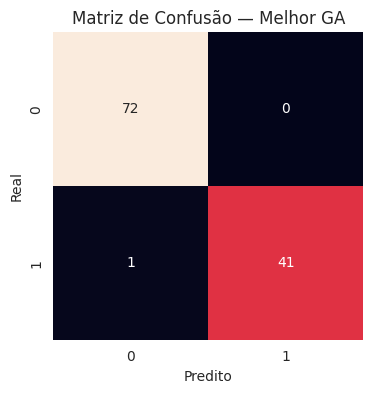

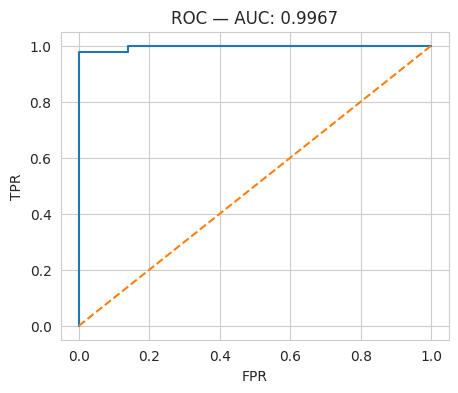

,Grupo,recall,n
0,Maior de 50 anos,0.958333,72
1,Entre 30 e 50 anos,1.000000,32
2,Menor que 30 anos,1.000000,10
3,Amarela,0.857143,19
4,Parda,1.000000,25
5,Indígena,1.000000,23
6,Branca,1.000000,25
7,Preta,1.000000,22



Gap de Recall (GA): 0.0923


In [ ]:
# Recupera o pipeline treinado do melhor resultado do GA a partir do dicionário best_metrics.
best_pipe = best_metrics["pipe"]

# Gera as previsões de classe (0/1) do modelo otimizado no conjunto de teste.
y_pred_ga = best_pipe.predict(X_test)

# Gera as probabilidades da classe positiva (Maligno = 1) no conjunto de teste.
y_proba_ga = best_pipe.predict_proba(X_test)[:, 1]

# Calcula a matriz de confusão comparando valores reais e previstos do modelo GA.
cm_ga = confusion_matrix(y_test, y_pred_ga)

# Cria uma nova figura com tamanho definido para o gráfico da matriz de confusão.
plt.figure(figsize=(4,4))

# Plota a matriz de confusão como um heatmap com valores anotados e sem barra de cores.
sns.heatmap(cm_ga, annot=True, fmt="d", cbar=False)

# Define o título do gráfico da matriz de confusão.
plt.title("Matriz de Confusão — Melhor GA")

# Define o rótulo do eixo X como classe predita.
plt.xlabel("Predito")

# Define o rótulo do eixo Y como classe real.
plt.ylabel("Real")

# Exibe o gráfico da matriz de confusão.
plt.show()
print()

# ROC/AUC
# Calcula os valores de FPR e TPR para diferentes limiares usando probabilidades do modelo GA.
fpr, tpr, _ = roc_curve(y_test, y_proba_ga)

# Calcula a área sob a curva ROC (AUC) a partir de FPR e TPR.
roc_auc = auc(fpr, tpr)

# Cria uma nova figura com tamanho definido para o gráfico ROC.
plt.figure(figsize=(5,4))

# Plota a curva ROC do modelo (TPR vs FPR).
plt.plot(fpr, tpr)

# Plota a linha de referência (classificador aleatório) para comparação.
plt.plot([0,1],[0,1], linestyle="--")

# Define o título do gráfico incluindo o valor numérico da AUC.
plt.title(f"ROC — AUC: {roc_auc:.4f}")

# Define o rótulo do eixo X como taxa de falsos positivos (FPR).
plt.xlabel("FPR")

# Define o rótulo do eixo Y como taxa de verdadeiros positivos (TPR/Recall).
plt.ylabel("TPR")

# Exibe o gráfico ROC.
plt.show()
print()

# Equidade
# Calcula o recall por grupo proxy usando as previsões do modelo GA.
eq_ga_idade = recall_por_grupo(y_test, y_pred_ga, grupo_idade_test)
eq_ga_etnia = recall_por_grupo(y_test, y_pred_ga, etnia_test)

# Calcula o recall_gap de grupos demográficos do modelo GA
gap_ga = recall_gap(eq_ga_idade, eq_ga_etnia)

# Exibe a tabela de recall por grupo proxy para o modelo GA.
display(pd.concat([eq_ga_idade, eq_ga_etnia], ignore_index=True))

# Imprime o gap de recall (diferença entre melhor e pior grupo) do modelo GA.
print("\nGap de Recall (GA):", round(gap_ga, 4))

# 13 - Integração com LLM

O enunciado pede para gerar explicações em linguagem natural dos diagnósticos específicos e salvar as respostas do LLM para formar dataset para a fase 3.

## Estratégia adotada
- Utilizar o "gpt-4o-mini" (API paga da OPEN AI) por ser barato e robusto o suficiente para o caso
- Criar um **prompt template** com:
  - Contexto de assistente para profissionais especializados em saúde feminina
  - orientação para não fazer diagnóstico definitivo
  - manter privacidade e confidencialidade
  - fazer recomendação de próximos passos clínicos

- O prompt recebe os seguintes dados do conjunto de amostras do teste:
  - predição (benigno/maligno)
  - probabilidade

In [ ]:
# Prompt template (engenharia de prompt)
PROMPT_TEMPLATE = """Você é um assistente clínico para profissionais especializados em saúde da mulher.
Seu objetivo é explicar um resultado de triagem para câncer de mama de forma técnica e sensível.

Regras obrigatórias:
- NÃO forneça diagnóstico definitivo, tratamento ou aconselhamento médico. Seu papel é apenas interpretar o resultado da triagem do modelo.
- Mantenha total anonimato: NÃO assuma identidade da paciente, NÃO use dados pessoais e NÃO se refira a ela diretamente.
- Linguagem: Use termos técnicos apropriados para profissionais de saúde, mas mantenha um tom respeitoso e sensível ao contexto feminino.
- Orientação: Forneça recomendações práticas para os próximos passos clínicos que o profissional de saúde pode considerar (ex.: exames confirmatórios adicionais, encaminhamento para especialista).
- Concisão: Mantenha a resposta clara e objetiva, com no máximo 12 linhas.

Dados do caso (anônimos):
- Predição do modelo: {pred} (0=benigno, 1=maligno).
- Probabilidade estimada de malignidade: {proba:.3f}

Responda em português e use bullets quando útil.
"""


In [ ]:
# Define uma função para gerar explicações usando a API da OpenAI.
# Foi utilizado o modelo "gpt-4o-mini" por ser barato e robusto o suficiente para a aplicação em questão
def llm_explain_openai(prompt: str, model: str = "gpt-4o-mini") -> str:

    """Chamada OpenAI. Requer API key salva em OPENAI_API_KEY."""

    # Instancia o cliente da OpenAI usando a chave OPENAI_API_KEY.
    # A chave OPENAI_API_KEY já é definida e verificada globalmente em uma célula anterior.
    client = OpenAI(api_key=OPENAI_API_KEY)

    # Envia o prompt para o modelo especificado e solicita uma resposta.
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2
    )

    # Retorna o conteúdo textual da resposta gerada pelo modelo.
    return resp.choices[0].message.content

## 13.1 - Gera explicações para um conjunto de amostras e salva o dataset (preparo para a Fase 3)

Vamos:
- selecionar N casos do conjunto de teste
- gerar prompt + resposta (OpenAI ou fallback)
- salvar em CSV e JSONL

Esses arquivos serão a base para o fine-tuning na Fase 3.

Caso a Fase 3 exija saídas para todo o conjunto de dados ou para todo o conjunto de teste, isto pode ser facilmente ajustado aqui.

In [ ]:
import openai
import os

# Repassa a chave recuperada para o ambiente do sistema e para a biblioteca
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
openai.api_key = OPENAI_API_KEY

# Define o número máximo de amostras
N_SAMPLES = 25

# Seleciona aleatoriamente os índices
sample_idx = X_test.sample(n=min(N_SAMPLES, len(X_test)), random_state=RANDOM_STATE).index

rows = []

for idx in sample_idx:
    x_row = X_test.loc[idx]
    pred = int(best_pipe.predict(x_row.to_frame().T)[0])
    pred_texto = 'benigno' if pred == 0 else 'maligno'
    proba = float(best_pipe.predict_proba(x_row.to_frame().T)[0, 1])

    prompt = PROMPT_TEMPLATE.format(pred=pred_texto, proba=proba)

    # Se o erro persistir, verifique se a função llm_explain_openai
    # aceita a chave como argumento, ex: llm_explain_openai(prompt, api_key=OPENAI_API_KEY)
    explanation = llm_explain_openai(prompt)

    rows.append({
        "id": int(idx),
        "pred": pred,
        "proba_maligno": proba,
        "prompt": prompt,
        "llm_response": explanation
    })

llm_df = pd.DataFrame(rows)
display(llm_df.head(3))

,id,pred,proba_maligno,prompt,llm_response
0,177,1,0.984393,Você é um assistente clínico para profissionai...,O resultado da triagem indica uma predição de ...
1,455,0,0.479987,Você é um assistente clínico para profissionai...,O resultado da triagem indica uma predição de ...
2,505,0,0.000072,Você é um assistente clínico para profissionai...,O resultado da triagem indica uma predição de ...


In [ ]:
# Salvando dataset para Fase 3
# Define o caminho onde o arquivo CSV com as explicações será salvo.
csv_path = "/fase2_llm_explanations.csv"

# Define o caminho onde o arquivo JSONL (formato comum para fine-tuning) será salvo.
jsonl_path = "/fase2_llm_explanations.jsonl"

# Create the directory if it doesn't exist
# Cria o diretório de destino caso ele ainda não exista.
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

# Salva o DataFrame llm_df em formato CSV sem incluir o índice.
llm_df.to_csv(csv_path, index=False)

# Abre o arquivo JSONL em modo de escrita com codificação UTF-8.
with open(jsonl_path, "w", encoding="utf-8") as f:

    # Percorre cada linha do DataFrame para criar registros individuais.
    for _, row in llm_df.iterrows():

        # Cria um dicionário contendo o prompt e a resposta da LLM.
        record = {
            "prompt": row["prompt"],
            "completion": row["llm_response"]
        }

        # Converte o dicionário para JSON e escreve uma linha por registro no arquivo.
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

# Exibe mensagem informando que os arquivos foram gerados.
print("Arquivos gerados:")

# Exibe o caminho do arquivo CSV gerado.
print(csv_path)

# Exibe o caminho do arquivo JSONL gerado.
print(jsonl_path)

Arquivos gerados:
/fase2_llm_explanations.csv
/fase2_llm_explanations.jsonl


# 14 - Avaliação qualitativa das respostas da LLM

As respostas da LLM nos seguintes atenderam os seguintes aspectos: tiveram precisão médica (não alucinaram e nem deram diagnóstico definitivo), apresentaram orientações práticas de próximos passos coerentes, concisos e coesos, a linguagem utilizada foi sensível e respeitosa, além de ter sido clara e útil ao profissional de saúde.
Segue abaixo exemplo de resposta da LLM.




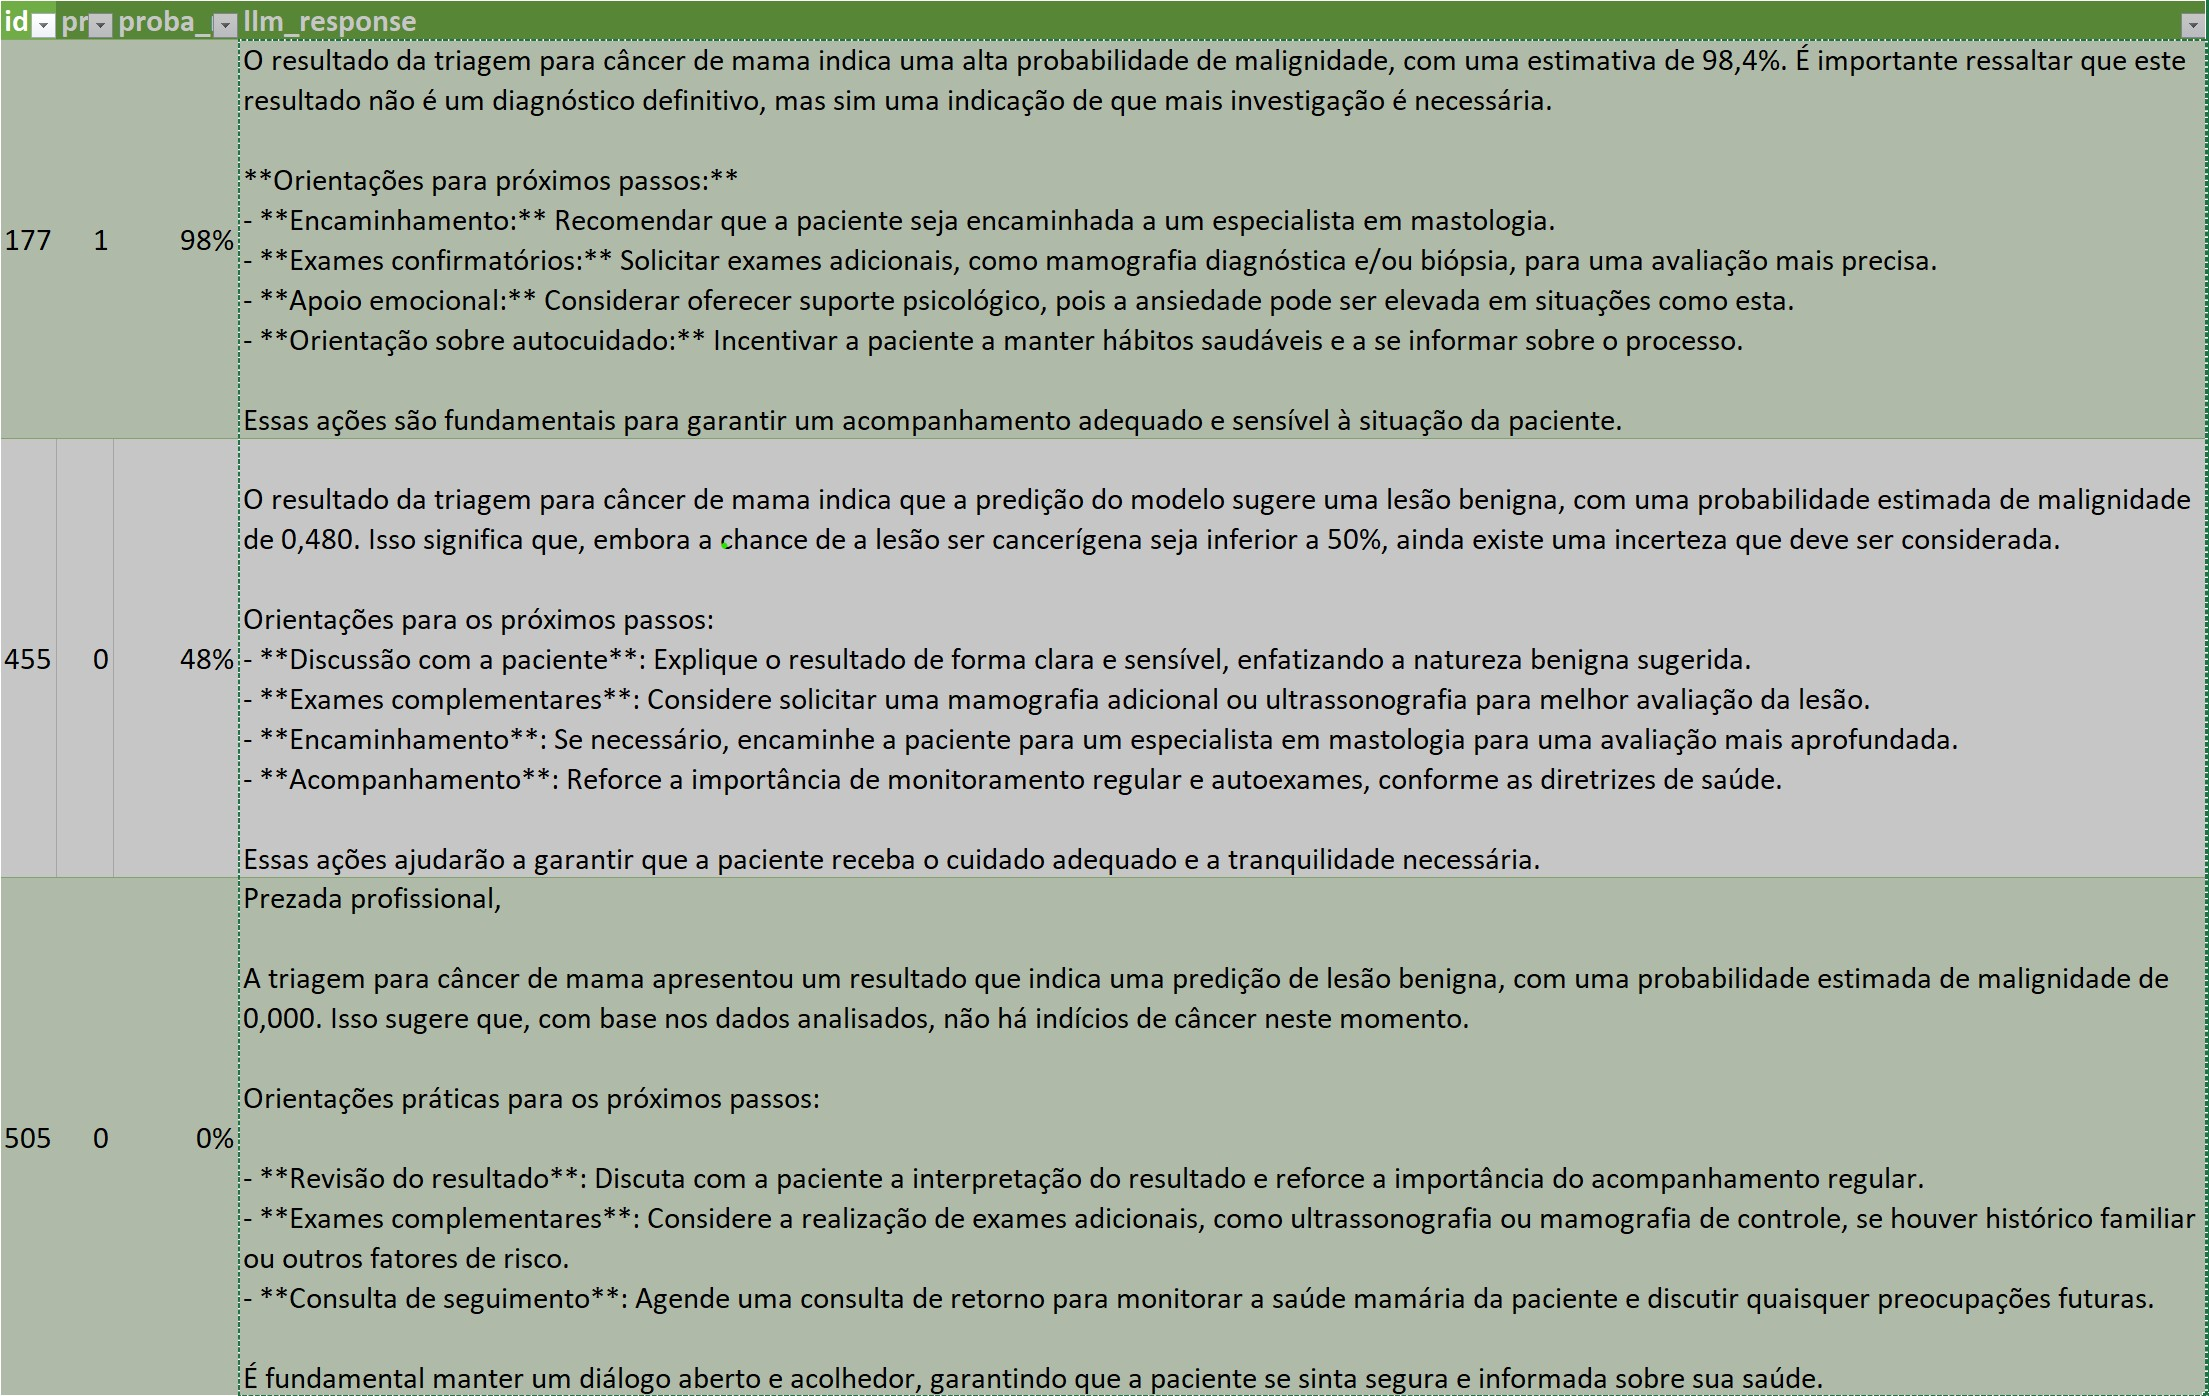